# 05. Handoffs - 상태 기반 에이전트 전환

> Handoff는 한 에이전트가 다른 에이전트로 **흐름을 넘기는** 패턴이에요. `current_step` 상태 변수와 `@wrap_model_call` 만으로 가벼운 단계 전환을 만들어 봅니다.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. Handoffs 패턴의 핵심 개념과 Supervisor 패턴과의 차이를 설명할 수 있어요
2. `current_step` 상태 변수와 `@wrap_model_call` 미들웨어를 사용해 단일 에이전트 Handoffs를 구현할 수 있어요
3. `tool_call_id` 페어링 규칙을 이해하고 올바른 `ToolMessage` 응답을 구성할 수 있어요
4. `STEP_CONFIG` 딕셔너리로 단계별 프롬프트와 도구를 동적으로 전환하는 패턴을 설계할 수 있어요

## 사전 지식

- Part 5 `create_agent` 기반 에이전트 생성
- Part 6 `@wrap_model_call` 미들웨어 기초
- 이전 노트북 `04-Multi-Agent-Supervisor.ipynb` — LLM 기반 Supervisor 패턴

## Handoffs 패턴 개요

이전 노트북에서 배운 Supervisor 패턴은 LLM이 매번 다음 에이전트를 결정해요. 반면 **Handoffs 패턴**은 에이전트 자신이 상태 변수를 보고 행동 방식을 바꾸는 설계예요.

> 🎯 **강의 포인트**: Handoffs 패턴은 **공장의 컨베이어 벨트**와 같아요. 원재료(사용자 요청)가 1번 공정(보증 확인) → 2번 공정(문제 분류) → 3번 공정(해결 처리)을 순서대로 거쳐요. Supervisor처럼 "다음 누구?" 하고 매번 물어보는 게 아니라, `current_step` 변수가 "지금 2번 공정이야"라고 알려주면 그에 맞는 도구와 프롬프트가 자동으로 세팅돼요.

### 두 가지 구현 방식

| 방식 | 핵심 요소 | 비유 | 특징 |
|------|----------|------|------|
| **단일 에이전트 + 미들웨어** | `current_step` + `@wrap_model_call` | 만능 직원이 다른 모자를 쓰는 것 | 하나의 에이전트가 단계별로 행동 변경, 권장 방식 |
| **다중 서브그래프** | `transfer_to_*` 도구 + 서브그래프 | 진짜 다른 직원에게 업무를 넘기는 것 | 에이전트 간 명시적 제어권 이전, 복잡한 아키텍처 |

### 핵심 아이디어: 상태 변수로 행동을 바꾼다

```python
# current_step 값에 따라 다른 프롬프트와 도구를 사용해요
STEP_CONFIG = {
    "warranty_check": {"prompt": "보증 확인 전문가", "tools": [check_warranty]},
    "issue_classify": {"prompt": "문제 분류 전문가", "tools": [classify_issue]},
    "resolve":        {"prompt": "문제 해결 전문가", "tools": [create_ticket]},
}
```

> 🔑 **핵심 개념**: Handoffs 패턴에서 "누가 다음인가"를 결정하는 것은 별도 Supervisor가 아니에요. **상태에 저장된 `current_step` 값** 자체가 에이전트의 행동을 결정해요. 단계 전환은 `Command(update={"current_step": "next_step"}, goto=...)` 한 줄로 이루어져요.

### Supervisor 패턴과 비교

| 항목 | Supervisor 패턴 | Handoffs 패턴 |
|------|----------------|---------------|
| **라우팅 주체** | 별도 Supervisor LLM | 상태 변수 (`current_step`) |
| **전환 비용** | 매번 LLM 호출 (비용 발생) | 상태 값 변경만 (비용 없음) |
| **흐름 예측성** | 낮음 (LLM이 판단) | 높음 (규칙 기반, 결정론적) |
| **구조** | 여러 에이전트 | 하나의 에이전트 (권장) |
| **적합한 경우** | 복잡한 동적 라우팅 | 미리 정의된 워크플로우 |

### 전체 시스템 아키텍처 (단일 에이전트 방식)

```mermaid
flowchart TD
    U(["사용자 요청<br/>User Request"]) --> A
    A(["단일 에이전트<br/>Single Agent"]) --> MW
    MW(["미들웨어<br/>wrap_model_call"]) --> SC
    SC{"current_step<br/>확인"}
    SC -->|"warranty_check"| W(["보증 확인<br/>단계"])
    SC -->|"issue_classify"| I(["문제 분류<br/>단계"])
    SC -->|"resolve"| R(["해결 처리<br/>단계"])
    W -->|"Command(update)"| SC
    I -->|"Command(update)"| SC
    R --> FIN(["완료<br/>END"])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef decision fill:#fce8d4,stroke:#fd7e14,color:#7d3a04

    class U input
    class A,MW process
    class SC decision
    class W,I,R storage
    class FIN output
```

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등을 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택 사항)
# ---------------------------------------------------
# 실행 흐름을 시각적으로 확인하고 싶다면 아래 주석을 해제하세요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "Multi-Agent-Handoffs"

## 모델 설정

LangChain V1의 `init_chat_model`로 모델을 초기화해요. 기본 모델은 비용 효율적인 `gpt-4o-mini`를 사용해요.

In [3]:
# ---------------------------------------------------
# 모델 초기화
# ---------------------------------------------------
from langchain.chat_models import init_chat_model

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 다른 모델로 변경하려면:
#   Anthropic: "anthropic:claude-sonnet-4-5"
#   Ollama 로컬: "ollama:llama3"
model = init_chat_model("openai:gpt-4o-mini")
# 모델 초기화 완료: gpt-4o-mini

## 1. ToolMessage 페어링 규칙

Handoffs 패턴에서 도구 호출 결과를 올바르게 전달하려면 `ToolMessage`와 `AIMessage(tool_calls)`의 페어링을 맞춰야 해요.

### tool_call_id 필수 매칭

LLM이 도구를 호출하면 각 호출에는 고유한 `tool_call_id`가 생성돼요. `ToolMessage`는 반드시 이 `tool_call_id`를 포함해야 해요.

```
AIMessage(
    tool_calls=[{"id": "call_abc123", "name": "transfer_to_sales", "args": {...}}]
)
    ↓ 반드시 페어링
ToolMessage(
    tool_call_id="call_abc123",  # 동일한 id!
    content="전환 완료"
)
```

> ⚠️ **자주 하는 실수**: `tool_call_id`를 누락하거나 다른 값을 사용하면 LLM이 도구 응답을 인식하지 못해요. 대화 이력이 깨지고 에이전트가 무한 루프에 빠질 수 있어요.

> 🔑 **핵심 개념**: 서브그래프 방식에서 에이전트 간 핸드오프 시 반드시 `AIMessage(tool_calls=...)` + `ToolMessage(tool_call_id=...)` 쌍을 함께 전달해야 해요. 이 쌍이 "제어권 이전 완료" 신호예요.

In [4]:
# ---------------------------------------------------
# ToolMessage 페어링 규칙 확인
# ---------------------------------------------------
# tool_call_id 매칭이 왜 중요한지 직접 확인해봐요
from langchain.messages import AIMessage, ToolMessage, HumanMessage

# 잘못된 예: tool_call_id 불일치
ai_msg = AIMessage(
    content="",
    tool_calls=[{"id": "call_abc123", "name": "transfer_to_sales", "args": {}}]
)
wrong_tool_msg = ToolMessage(
    tool_call_id="call_wrong_id",  # 불일치! 오류 발생
    content="전환 완료"
)

# 올바른 예: tool_call_id 일치
correct_tool_msg = ToolMessage(
    tool_call_id="call_abc123",  # AIMessage의 id와 동일
    content="전환 완료"
)

# === ToolMessage 페어링 규칙 ===
print(f"AIMessage tool_call_id: {ai_msg.tool_calls[0]['id']}")
print(f"잘못된 ToolMessage id:  {wrong_tool_msg.tool_call_id} -> 불일치!")
print(f"올바른 ToolMessage id:  {correct_tool_msg.tool_call_id} -> 일치!")
# tool_call_id가 일치해야 LLM이 도구 응답을 올바르게 인식해요

AIMessage tool_call_id: call_abc123
잘못된 ToolMessage id:  call_wrong_id -> 불일치!
올바른 ToolMessage id:  call_abc123 -> 일치!


## 2. 상태(State) 정의

Handoffs 패턴의 핵심은 `current_step` 상태 변수예요. 이 값이 에이전트의 행동을 결정해요.

### SupportState 구성

| 필드 | 타입 | 역할 |
|------|------|------|
| `messages` | `list[BaseMessage]` (add_messages) | 전체 대화 이력 (자동 누적) |
| `current_step` | `str` | 현재 워크플로우 단계 (미들웨어가 읽음) |
| `warranty_status` | `str` (NotRequired) | 보증 확인 결과 저장 |
| `issue_type` | `str` (NotRequired) | 문제 유형 분류 결과 저장 |

> 💡 **실무 팁**: `NotRequired[str]`은 해당 필드가 없어도 오류가 발생하지 않아요. 워크플로우 초기에는 `warranty_status`나 `issue_type`이 없지만, 단계가 진행되면서 채워져요. 이런 "점진적으로 채워지는" 상태 설계가 Handoffs 패턴의 특징이에요.

In [5]:
# ---------------------------------------------------
# SupportState 정의
# ---------------------------------------------------
# current_step으로 에이전트 행동을 제어해요
from typing_extensions import TypedDict, NotRequired
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing import Annotated


class SupportState(TypedDict):
    """고객 지원 워크플로우의 공유 상태
    
    current_step 값에 따라 에이전트 행동이 달라져요.
    warranty_status와 issue_type은 단계가 진행되면서 채워져요.
    """

    # 전체 대화 이력: add_messages reducer로 자동 누적
    messages: Annotated[list[BaseMessage], add_messages]

    # 현재 워크플로우 단계: 미들웨어가 이 값을 보고 행동을 변경해요
    current_step: str  # "warranty_check" | "issue_classify" | "resolve"

    # 보증 확인 결과: warranty_check 단계에서 채워져요
    warranty_status: NotRequired[str]  # "valid" | "expired" | "unknown"

    # 문제 유형: issue_classify 단계에서 채워져요
    issue_type: NotRequired[str]  # "hardware" | "software" | "billing" | "other"

    # 고객 만족도 점수: satisfaction_survey 단계에서 채워져요
    survey_score: NotRequired[int]  # 1~5


# SupportState 정의 완료
#   - messages: 대화 이력 (누적)
#   - current_step: 현재 단계 (에이전트 행동 결정)
#   - warranty_status: 보증 상태 (단계 진행 시 채워짐)
#   - issue_type: 문제 유형 (단계 진행 시 채워짐)

## 3. STEP_CONFIG - 단계별 설정 딕셔너리

`STEP_CONFIG`는 각 단계의 시스템 프롬프트, 도구, 의존성을 한 곳에 모아두는 설정 딕셔너리예요.

### 구조

```python
STEP_CONFIG = {
    "단계명": {
        "system_prompt": "이 단계에서 에이전트가 따를 지시사항",
        "tools": [이 단계에서 사용할 도구 목록],
        "next_step": "다음으로 이동할 단계명"  # 선택 사항
    }
}
```

> 🎯 **강의 포인트**: `STEP_CONFIG`의 핵심은 **설정과 로직의 분리**예요. 새로운 단계를 추가하려면 딕셔너리에 항목 하나만 추가하면 돼요. 에이전트 로직 코드는 건드리지 않아도 됩니다. 이것이 유지보수하기 쉬운 설계예요.

> 💡 **실무 팁**: 실제 고객 지원 시스템에서는 `STEP_CONFIG`를 외부 설정 파일(YAML, JSON)로 관리하기도 해요. 비즈니스 로직 변경이 코드 수정 없이 가능해져요.

In [6]:
# ---------------------------------------------------
# 각 단계에서 사용할 도구(Tool) 정의
# ---------------------------------------------------
from langchain.tools import tool


@tool
def check_warranty(product_id: str) -> str:
    """제품 보증 상태를 확인해요. product_id로 조회해요."""
    # 실제 환경에서는 DB나 API를 호출하지만, 여기서는 시뮬레이션해요
    warranty_db = {
        "PRD001": "valid",
        "PRD002": "expired",
        "PRD003": "valid",
    }
    status = warranty_db.get(product_id, "unknown")
    return f"제품 {product_id}의 보증 상태: {status}"


@tool
def classify_issue(description: str) -> str:
    """고객 문제를 유형별로 분류해요. 설명을 분석해 카테고리를 반환해요."""
    # 간단한 키워드 기반 분류 (실제로는 LLM이 분류하도록 설계)
    description_lower = description.lower()
    if any(k in description_lower for k in ["화면", "버튼", "배터리", "충전", "하드웨어"]):
        return "hardware"
    elif any(k in description_lower for k in ["앱", "소프트웨어", "업데이트", "오류", "crash"]):
        return "software"
    elif any(k in description_lower for k in ["환불", "청구", "결제", "요금", "billing"]):
        return "billing"
    else:
        return "other"


@tool
def create_support_ticket(issue_type: str, description: str, priority: str = "normal") -> str:
    """고객 지원 티켓을 생성해요. 문제 유형, 설명, 우선순위를 입력받아요."""
    import uuid
    ticket_id = f"TICKET-{str(uuid.uuid4())[:8].upper()}"
    return (
        f"티켓 생성 완료: {ticket_id}\n"
        f"  유형: {issue_type}\n"
        f"  설명: {description}\n"
        f"  우선순위: {priority}\n"
        f"  예상 처리 시간: 24시간 이내"
    )


@tool
def provide_solution(issue_type: str, warranty_status: str) -> str:
    """문제 유형과 보증 상태에 따른 해결책을 제공해요."""
    if warranty_status == "valid":
        if issue_type == "hardware":
            return "보증 기간 내 하드웨어 문제: 무상 수리 또는 교환을 진행해 드려요."
        elif issue_type == "software":
            return "보증 기간 내 소프트웨어 문제: 공식 업데이트를 시도하고 복구 모드를 안내해 드려요."
        else:
            return "보증 기간 내 문제: 담당 팀이 48시간 내 연락드릴 예정이에요."
    else:
        return "보증 기간 만료: 유상 수리 서비스를 안내해 드려요. 가까운 서비스 센터를 방문해 주세요."


# 도구 정의 완료
print(f"  - check_warranty: 보증 상태 확인")
print(f"  - classify_issue: 문제 유형 분류")
print(f"  - create_support_ticket: 지원 티켓 생성")
print(f"  - provide_solution: 해결책 제공")

  - check_warranty: 보증 상태 확인
  - classify_issue: 문제 유형 분류
  - create_support_ticket: 지원 티켓 생성
  - provide_solution: 해결책 제공


In [7]:
# ---------------------------------------------------
# STEP_CONFIG: 단계별 프롬프트 + 도구 + 의존성 매핑
# ---------------------------------------------------
# 새 단계 추가 시 여기에만 항목을 추가하면 돼요
STEP_CONFIG = {
    # 1단계: 보증 확인
    "warranty_check": {
        "system_prompt": (
            "당신은 고객 지원팀의 보증 확인 전문가예요. "
            "고객이 제공한 제품 ID를 확인하고 check_warranty 도구로 보증 상태를 조회해요. "
            "보증 상태를 확인한 후, 이슈 분류 단계로 넘어가야 한다고 안내해요."
        ),
        "tools": [check_warranty],
        "next_step": "issue_classify",
    },
    # 2단계: 문제 분류
    "issue_classify": {
        "system_prompt": (
            "당신은 고객 지원팀의 문제 분류 전문가예요. "
            "고객의 문제 설명을 분석해 classify_issue 도구로 문제 유형을 파악해요. "
            "분류 후 해결 단계로 넘어간다고 안내해요."
        ),
        "tools": [classify_issue],
        "next_step": "resolve",
    },
    # 3단계: 해결 처리
    "resolve": {
        "system_prompt": (
            "당신은 고객 지원팀의 해결사예요. "
            "이전 단계에서 수집된 정보를 바탕으로 provide_solution 도구로 해결책을 제시하고, "
            "필요하면 create_support_ticket 도구로 티켓을 생성해요. "
            "고객에게 친절하고 명확하게 최종 답변을 제공해요."
        ),
        "tools": [provide_solution, create_support_ticket],
        "next_step": None,  # 마지막 단계: 더 이상 전환 없음
    },
}

# STEP_CONFIG 정의 완료
for step_name, config in STEP_CONFIG.items():
    tools_names = [t.name for t in config["tools"]]
    next_step = config.get("next_step", "없음")
    print(f"  [{step_name}] 도구: {tools_names} → 다음: {next_step}")

  [warranty_check] 도구: ['check_warranty'] → 다음: issue_classify
  [issue_classify] 도구: ['classify_issue'] → 다음: resolve
  [resolve] 도구: ['provide_solution', 'create_support_ticket'] → 다음: None


## 4. 미들웨어 기반 단일 에이전트 Handoffs (권장 방식)

### @wrap_model_call 미들웨어

`@wrap_model_call`은 LLM 호출 전후에 실행되는 미들웨어예요. Handoffs 패턴에서는 **LLM 호출 직전**에 `current_step`을 확인해 시스템 프롬프트와 도구를 동적으로 교체해요.

```python
@wrap_model_call
def step_switcher(request, call_next):
    # LLM 호출 전: current_step 확인
    step = request.state["current_step"]
    config = STEP_CONFIG[step]
    
    # 시스템 프롬프트와 도구를 이 단계의 설정으로 교체
    modified = request.override(
        system_prompt=config["system_prompt"],
        tools=config["tools"]
    )
    
    # 수정된 설정으로 LLM 호출
    return call_next(modified)
```

> 🎯 **강의 포인트**: 미들웨어 방식의 장점은 **에이전트 코드를 수정하지 않고** 행동을 바꿀 수 있다는 점이에요. `STEP_CONFIG`만 편집하면 새로운 단계를 추가하거나 기존 단계의 프롬프트를 수정할 수 있어요. 관심사 분리(Separation of Concerns)의 좋은 예예요.

> ⚠️ **자주 하는 실수**: `request.state`는 읽기 전용이에요. 상태를 변경하려면 반드시 `Command(update={...})`를 통해야 해요. 미들웨어 안에서 직접 상태를 수정하려 하면 오류가 발생해요.

In [8]:
# ---------------------------------------------------
# @wrap_model_call 미들웨어 정의
# ---------------------------------------------------
# LLM 호출 전에 current_step을 보고 프롬프트와 도구를 교체해요
from langchain.agents.middleware import wrap_model_call


@wrap_model_call
def step_switcher(request, call_next):
    """current_step에 따라 LLM의 시스템 프롬프트와 도구를 동적으로 교체해요.
    
    LLM이 호출될 때마다 이 미들웨어가 먼저 실행돼요:
    1. 현재 상태에서 current_step 값을 읽어요
    2. STEP_CONFIG에서 해당 단계의 설정을 가져와요
    3. request.override()로 프롬프트와 도구를 교체해요
    4. 수정된 요청으로 LLM을 호출해요
    """
    # 현재 단계 확인: 없으면 첫 단계인 "warranty_check"로 시작
    current_step = request.state.get("current_step", "warranty_check")
    
    # STEP_CONFIG에서 이 단계의 설정 가져오기
    if current_step not in STEP_CONFIG:
        # 알 수 없는 단계면 그대로 진행
        return call_next(request)
    
    step_config = STEP_CONFIG[current_step]
    
    # LLM 요청을 이 단계의 프롬프트와 도구로 오버라이드
    modified_request = request.override(
        system_prompt=step_config["system_prompt"],
        tools=step_config["tools"],
    )
    
    print(f"[미들웨어] 현재 단계: {current_step}")
    print(f"[미들웨어] 사용 도구: {[t.name for t in step_config['tools']]}")
    
    # 수정된 요청으로 LLM 호출
    return call_next(modified_request)


# step_switcher 미들웨어 정의 완료

## 5. Command로 단계 전환하기

에이전트가 현재 단계 작업을 완료한 뒤 다음 단계로 이동하려면 `Command` 객체를 사용해요.

### Command 사용 방법

```python
from langgraph.types import Command

# 다음 단계로 이동: 상태 업데이트 + 노드 이동
return Command(
    update={
        "current_step": "issue_classify",  # 상태에 다음 단계 기록
        "warranty_status": "valid",         # 이번 단계 결과 저장
    },
    goto="support_agent",  # 다시 같은 노드로 (미들웨어가 단계 변경 감지)
)
```

> 🔑 **핵심 개념**: 단일 에이전트 방식에서 `goto`는 자기 자신 노드를 가리켜요. 같은 에이전트가 다시 호출되지만, `current_step`이 변경됐으므로 미들웨어가 다른 프롬프트와 도구를 적용해요. 마치 같은 배우가 다른 대본으로 연기하는 것과 같아요.

### 노드 함수 구조

```python
def support_agent_node(state: SupportState) -> Command:
    # 1. 현재 단계 확인
    # 2. 미들웨어가 적용된 에이전트 실행
    # 3. 결과를 상태에 저장하고 다음 단계로 Command 반환
```

In [9]:
# ---------------------------------------------------
# 단일 에이전트 노드 함수 정의
# ---------------------------------------------------
# current_step에 따라 동적으로 행동이 바뀌는 에이전트 노드예요
from langchain.agents import create_agent
from langgraph.types import Command
from langgraph.checkpoint.memory import MemorySaver

# 지원 에이전트 생성: 미들웨어가 단계별로 프롬프트/도구를 교체해요
# 초기 도구 목록은 첫 번째 단계 것을 사용하지만, 미들웨어가 교체해요
support_agent_executor = create_agent(
    model,
    tools=STEP_CONFIG["warranty_check"]["tools"],  # 초기값 (미들웨어가 교체)
    middleware=[step_switcher],  # 단계 전환 미들웨어 적용
    system_prompt=STEP_CONFIG["warranty_check"]["system_prompt"],  # 초기값
)


def support_agent_node(state: SupportState):
    """미들웨어 기반 단일 에이전트 노드예요.
    
    current_step을 확인해 단계 전환 여부를 결정해요.
    마지막 단계(resolve)에서는 Command 없이 결과를 반환해요.
    """
    # 현재 단계 확인
    current_step = state.get("current_step", "warranty_check")
    
    print(f"\n[에이전트 노드] 단계: {current_step}")
    
    # 에이전트 실행: 미들웨어가 현재 단계의 프롬프트와 도구를 적용해요
    result = support_agent_executor.invoke(state)
    
    # 다음 단계 결정
    step_config = STEP_CONFIG.get(current_step, {})
    next_step = step_config.get("next_step")
    
    # 에이전트 응답에서 단계 관련 정보 추출
    last_message = result["messages"][-1]
    
    if next_step is None:
        # 마지막 단계: 메시지와 최종 단계에서 추출한 상태를 반환하고 종료
        final_updates = {"messages": result["messages"]}
        if current_step == "satisfaction_survey":
            for msg in result["messages"]:
                if hasattr(msg, "content") and isinstance(msg.content, str):
                    for score in range(1, 6):
                        if f"{score}점" in msg.content or f"{score}/5" in msg.content:
                            final_updates["survey_score"] = score
                            break
                    if "survey_score" in final_updates:
                        break
        return final_updates
    
    # 중간 단계: 상태 업데이트 + 다음 단계로 이동
    updates = {
        "messages": result["messages"],
        "current_step": next_step,
    }
    
    # warranty_check 단계에서 보증 상태 추출 (도구 결과에서)
    if current_step == "warranty_check":
        for msg in result["messages"]:
            if hasattr(msg, "content") and isinstance(msg.content, str):
                if "valid" in msg.content:
                    updates["warranty_status"] = "valid"
                elif "expired" in msg.content:
                    updates["warranty_status"] = "expired"
    
    # issue_classify 단계에서 문제 유형 추출
    if current_step == "issue_classify":
        for msg in result["messages"]:
            if hasattr(msg, "content") and isinstance(msg.content, str):
                for issue_t in ["hardware", "software", "billing", "other"]:
                    if issue_t in msg.content.lower():
                        updates["issue_type"] = issue_t
                        break
    
    return Command(
        update=updates,
        goto="support_agent",  # 같은 노드로 다시 이동 (단계만 변경됨)
    )


# support_agent_node 정의 완료
#   - 단계: warranty_check → issue_classify → resolve
#   - 미들웨어가 각 단계의 프롬프트와 도구를 자동으로 교체해요

## 6. 그래프 구성 및 실행

단일 에이전트 Handoffs에서 그래프 구조는 매우 단순해요. 노드 하나, 간단한 엣지 구조만 있어요.

```
START → support_agent → END
        (내부에서 Command로 자신을 반복 호출)
```

> 💡 **실무 팁**: 단일 에이전트 방식은 그래프 구조가 단순해서 디버깅과 테스트가 쉬워요. 복잡한 워크플로우도 STEP_CONFIG 설정과 미들웨어로 제어하기 때문에 그래프 코드는 거의 변경되지 않아요.

In [10]:
# ---------------------------------------------------
# StateGraph 구성 및 컴파일
# ---------------------------------------------------
# 단일 에이전트 방식은 노드가 하나뿐이에요
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# StateGraph 초기화
workflow = StateGraph(SupportState)

# 노드 추가: 단일 에이전트 노드 하나만 추가해요
workflow.add_node("support_agent", support_agent_node)

# 엣지 추가
workflow.add_edge(START, "support_agent")  # 시작 → 에이전트
workflow.add_edge("support_agent", END)     # 에이전트 → 종료 (Command로 반복 가능)

# 메모리 체크포인터로 컴파일 (대화 세션 유지)
support_graph = workflow.compile(checkpointer=MemorySaver())

# StateGraph 컴파일 완료
#   구조: START → support_agent → END
#   내부적으로 Command가 단계 전환을 처리해요

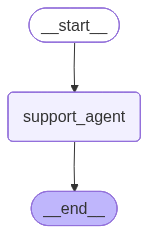

In [11]:
# ---------------------------------------------------
# 그래프 구조 시각화
# ---------------------------------------------------
# 그래프 흐름: START → support_agent → END (내부에서 Command로 자기 자신을 반복 호출)
# support_agent: current_step 값에 따라 미들웨어가 프롬프트와 도구를 동적으로 교체해요
# 단계: warranty_check → issue_classify → resolve
# Command(goto="support_agent"): 같은 노드를 다시 호출하되 current_step만 변경해요
from IPython.display import Image, display

display(Image(support_graph.get_graph().draw_mermaid_png()))


In [12]:
# ---------------------------------------------------
# 고객 지원 워크플로우 실행
# ---------------------------------------------------
# 3단계 워크플로우: 보증확인 → 문제분류 → 해결처리
import uuid
from langchain_core.runnables import RunnableConfig

# 실행 설정
config = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": str(uuid.uuid4())}
)

# 초기 상태: 첫 번째 단계와 고객 메시지
initial_state = {
    "messages": [
        HumanMessage(
            content=(
                "안녕하세요. 제품 ID가 PRD001인데 화면이 깜빡거려요. "
                "어떻게 해야 하나요?"
            )
        )
    ],
    "current_step": "warranty_check",  # 보증 확인 단계에서 시작
}

# === 고객 지원 Handoffs 워크플로우 실행 ===
print(f"고객 문의: {initial_state['messages'][0].content}")
# ------------------------------------------------------------

# 스트리밍으로 실행하여 단계별 진행 확인
for chunk in support_graph.stream(initial_state, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n[{node_name}]")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, "content") and msg.content:
                    msg_type = type(msg).__name__
                    content_preview = str(msg.content)[:300]
                    if len(str(msg.content)) > 300:
                        content_preview += "...(생략)"
                    print(f"  [{msg_type}]: {content_preview}")
        if "current_step" in node_output:
            print(f"  → 다음 단계: {node_output['current_step']}")
        if "warranty_status" in node_output:
            print(f"  → 보증 상태: {node_output['warranty_status']}")
        if "issue_type" in node_output:
            print(f"  → 문제 유형: {node_output['issue_type']}")

# === 워크플로우 완료 ===

고객 문의: 안녕하세요. 제품 ID가 PRD001인데 화면이 깜빡거려요. 어떻게 해야 하나요?

[에이전트 노드] 단계: warranty_check
[미들웨어] 현재 단계: warranty_check
[미들웨어] 사용 도구: ['check_warranty']
[미들웨어] 현재 단계: warranty_check
[미들웨어] 사용 도구: ['check_warranty']

[support_agent]
  [HumanMessage]: 안녕하세요. 제품 ID가 PRD001인데 화면이 깜빡거려요. 어떻게 해야 하나요?
  [ToolMessage]: 제품 PRD001의 보증 상태: valid
  [AIMessage]: 안녕하세요! 제품 ID가 PRD001인 제품의 보증 상태는 유효합니다. 화면 깜빡임 문제에 대해 이슈를 분류할 단계로 넘어가겠습니다. 

어떤 추가적인 문제나 증상에 대해 설명해 주실 수 있나요?
  → 다음 단계: issue_classify
  → 보증 상태: valid

[에이전트 노드] 단계: issue_classify
[미들웨어] 현재 단계: warranty_check
[미들웨어] 사용 도구: ['check_warranty']

[support_agent]
  [HumanMessage]: 안녕하세요. 제품 ID가 PRD001인데 화면이 깜빡거려요. 어떻게 해야 하나요?
  [ToolMessage]: 제품 PRD001의 보증 상태: valid
  [AIMessage]: 안녕하세요! 제품 ID가 PRD001인 제품의 보증 상태는 유효합니다. 화면 깜빡임 문제에 대해 이슈를 분류할 단계로 넘어가겠습니다. 

어떤 추가적인 문제나 증상에 대해 설명해 주실 수 있나요?
  [AIMessage]: 이 문제를 해결하기 위해 확인할 수 있는 몇 가지 사항은 다음과 같습니다:

1. **전원 연결**: 전원이 안정적으로 연결되어 있는지 확인해 주세요.
2. **케이블 확인**: 비디오 케이블이 제대로 연결되어 있는지, 손상이 없는지 점검해 주세요.
3. **모니터 

## 7. 멀티 에이전트 서브그래프 방식

두 번째 구현 방식은 **실제 여러 에이전트가 제어권을 넘기는** 서브그래프 방식이에요.

### 서브그래프 Handoffs 아키텍처

```mermaid
flowchart LR
    U(["사용자"]) --> W
    W(["보증 확인 에이전트"]) -->|"transfer_to_classify"| C
    C(["문제 분류 에이전트"]) -->|"transfer_to_resolve"| R
    R(["해결 에이전트"]) --> FIN(["완료"])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class U input
    class W,C,R process
    class FIN output
```

### 핸드오프 쌍 (Handoff Pair)

서브그래프 방식에서 에이전트 간 제어권 이전은 반드시 두 메시지의 쌍으로 이루어져요:

```
1. AIMessage(tool_calls=[{"name": "transfer_to_classify", ...}])  ← 이전 의도
2. ToolMessage(tool_call_id=..., content="분류 에이전트로 이전")    ← 이전 확인
```

> 🔑 **핵심 개념**: 핸드오프 쌍에서 `AIMessage`만 또는 `ToolMessage`만 전달하면 LLM이 대화 이력을 올바르게 파악하지 못해요. 두 메시지가 반드시 함께 다음 에이전트에게 전달되어야 해요.

> 💡 **실무 팁**: 단일 에이전트 방식(미들웨어)과 서브그래프 방식 중 어떤 걸 선택할까요? 미들웨어 방식은 코드가 간결하고 유지보수가 쉬워요. 서브그래프 방식은 각 에이전트가 완전히 독립적이어야 하거나, 에이전트마다 다른 모델을 사용하고 싶을 때 적합해요.

In [13]:
# ---------------------------------------------------
# 서브그래프 방식: transfer 도구 정의
# ---------------------------------------------------
# 에이전트 간 제어권 이전을 위한 도구예요
from langchain.tools import tool


@tool
def transfer_to_classify(warranty_result: str) -> str:
    """보증 확인 완료 후 문제 분류 에이전트로 제어권을 넘겨요.
    
    Args:
        warranty_result: 보증 확인 결과 문자열
    """
    return f"보증 확인 완료: {warranty_result}. 문제 분류 에이전트로 이전합니다."


@tool  
def transfer_to_resolve(issue_type: str) -> str:
    """문제 분류 완료 후 해결 에이전트로 제어권을 넘겨요.
    
    Args:
        issue_type: 분류된 문제 유형 (hardware/software/billing/other)
    """
    return f"문제 분류 완료: {issue_type}. 해결 에이전트로 이전합니다."


# transfer 도구 정의 완료
#   - transfer_to_classify: 보증 확인 → 문제 분류 이전
#   - transfer_to_resolve: 문제 분류 → 해결 이전

In [14]:
# ---------------------------------------------------
# 서브그래프 방식: 개별 에이전트 생성
# ---------------------------------------------------
# 각 에이전트가 자신의 단계를 처리하고 transfer 도구로 다음에게 넘겨요
from langchain.agents import create_agent

# 1. 보증 확인 에이전트
warranty_agent = create_agent(
    model,
    tools=[check_warranty, transfer_to_classify],
    system_prompt=(
        "당신은 보증 확인 전문가예요. "
        "check_warranty 도구로 제품 보증 상태를 확인하고, "
        "확인 완료 후 transfer_to_classify 도구로 문제 분류 에이전트에게 넘겨요."
    ),
)

# 2. 문제 분류 에이전트
classify_agent = create_agent(
    model,
    tools=[classify_issue, transfer_to_resolve],
    system_prompt=(
        "당신은 문제 분류 전문가예요. "
        "classify_issue 도구로 고객 문제를 분류하고, "
        "분류 완료 후 transfer_to_resolve 도구로 해결 에이전트에게 넘겨요."
    ),
)

# 3. 해결 처리 에이전트
resolve_agent = create_agent(
    model,
    tools=[provide_solution, create_support_ticket],
    system_prompt=(
        "당신은 고객 문제 해결 전문가예요. "
        "이전 단계에서 수집된 정보를 바탕으로 provide_solution으로 해결책을 제시하고, "
        "필요하면 create_support_ticket으로 티켓을 생성해요."
    ),
)

# 서브그래프 방식 에이전트 3개 생성 완료
#   - warranty_agent: 보증 확인 + transfer_to_classify
#   - classify_agent: 문제 분류 + transfer_to_resolve
#   - resolve_agent:  해결 처리

In [15]:
# ---------------------------------------------------
# 서브그래프 방식: 노드 함수 정의
# ---------------------------------------------------
# 핸드오프 쌍(AIMessage + ToolMessage)을 올바르게 처리해요
from langchain.messages import AIMessage, ToolMessage
from langgraph.types import Command


def warranty_node(state: SupportState):
    """보증 확인 노드: 작업 완료 후 classify 노드로 핸드오프해요."""
    result = warranty_agent.invoke(state)
    messages = result["messages"]
    
    # 보증 상태 추출
    warranty_status = "unknown"
    for msg in messages:
        if hasattr(msg, "content") and isinstance(msg.content, str):
            if "valid" in msg.content:
                warranty_status = "valid"
                break
            elif "expired" in msg.content:
                warranty_status = "expired"
                break
    
    # transfer_to_classify가 호출됐으면 다음 노드로 이동
    last_ai_msg = None
    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tc in msg.tool_calls:
                if tc["name"] == "transfer_to_classify":
                    last_ai_msg = msg
                    break
        if last_ai_msg:
            break
    
    if last_ai_msg:
        # 핸드오프 쌍: AIMessage(이전 의도) + ToolMessage(이전 확인)
        # 이 두 메시지를 classify_node에 전달해야 해요
        handoff_messages = [
            last_ai_msg,  # AIMessage with transfer tool_call
            ToolMessage(
                tool_call_id=last_ai_msg.tool_calls[0]["id"],  # 동일한 id 필수!
                content=f"보증 상태 확인 완료: {warranty_status}"
            )
        ]
        return Command(
            update={
                "messages": handoff_messages,
                "warranty_status": warranty_status,
                "current_step": "issue_classify",
            },
            goto="classify_node",  # 다음 노드로 이동
        )
    
    # transfer 없이 완료된 경우
    return {"messages": messages, "warranty_status": warranty_status}


def classify_node(state: SupportState):
    """문제 분류 노드: 작업 완료 후 resolve 노드로 핸드오프해요."""
    result = classify_agent.invoke(state)
    messages = result["messages"]
    
    # 문제 유형 추출
    issue_type = "other"
    for msg in messages:
        if hasattr(msg, "content") and isinstance(msg.content, str):
            for it in ["hardware", "software", "billing"]:
                if it in msg.content.lower():
                    issue_type = it
                    break
    
    # transfer_to_resolve가 호출됐으면 다음 노드로 이동
    last_ai_msg = None
    for msg in reversed(messages):
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tc in msg.tool_calls:
                if tc["name"] == "transfer_to_resolve":
                    last_ai_msg = msg
                    break
        if last_ai_msg:
            break
    
    if last_ai_msg:
        # 핸드오프 쌍 생성
        handoff_messages = [
            last_ai_msg,
            ToolMessage(
                tool_call_id=last_ai_msg.tool_calls[0]["id"],
                content=f"문제 분류 완료: {issue_type}"
            )
        ]
        return Command(
            update={
                "messages": handoff_messages,
                "issue_type": issue_type,
                "current_step": "resolve",
            },
            goto="resolve_node",
        )
    
    return {"messages": messages, "issue_type": issue_type}


def resolve_node(state: SupportState):
    """해결 처리 노드: 최종 해결책을 제공해요."""
    result = resolve_agent.invoke(state)
    return {"messages": result["messages"]}


# 서브그래프 노드 함수 3개 정의 완료
#   - warranty_node → classify_node (핸드오프 쌍 포함)
#   - classify_node → resolve_node (핸드오프 쌍 포함)
#   - resolve_node  → END

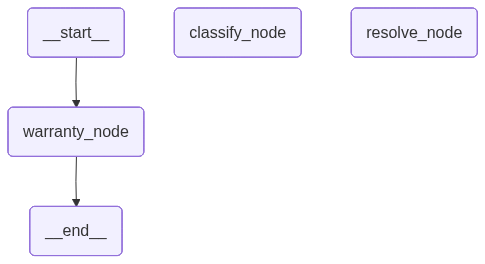

In [ ]:
# ---------------------------------------------------
# 서브그래프 방식: 그래프 구성 및 컴파일
# ---------------------------------------------------
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# 서브그래프 방식: 3개의 노드가 순서대로 연결돼요
subgraph_workflow = StateGraph(SupportState)

# 노드 추가
subgraph_workflow.add_node("warranty_node", warranty_node)
subgraph_workflow.add_node("classify_node", classify_node)
subgraph_workflow.add_node("resolve_node", resolve_node)

# 엣지: START에서 보증 확인으로 시작
# 이후 흐름은 각 노드의 Command가 결정해요
subgraph_workflow.add_edge(START, "warranty_node")
subgraph_workflow.add_edge("resolve_node", END)

# 컴파일
subgraph = subgraph_workflow.compile(checkpointer=MemorySaver())

# 서브그래프 컴파일 완료
#   구조: START → warranty_node → classify_node → resolve_node → END

# 그래프 흐름: START → warranty_node → classify_node → resolve_node → END
# warranty_node: 보증 상태를 확인하고 Command로 classify_node로 핸드오프해요
# classify_node: 문제 유형을 분류하고 Command로 resolve_node로 핸드오프해요
# resolve_node: 해결책을 제시하고 티켓을 생성해요
# 핸드오프 쌍: AIMessage(tool_calls) + ToolMessage(tool_call_id) 페어링 필수
display(Image(subgraph.get_graph().draw_mermaid_png()))


In [17]:
# ---------------------------------------------------
# 서브그래프 방식 실행
# ---------------------------------------------------
# 동일한 고객 문의로 두 방식의 결과를 비교해봐요
config2 = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": str(uuid.uuid4())}
)

# 서브그래프는 current_step 없이 시작해요 (warranty_node에서 시작하니까요)
initial_state2 = {
    "messages": [
        HumanMessage(
            content=(
                "안녕하세요. 제품 ID가 PRD002인데 앱이 계속 종료돼요. "
                "어떻게 해야 하나요?"
            )
        )
    ],
}

# === 서브그래프 방식 Handoffs 실행 ===
print(f"고객 문의: {initial_state2['messages'][0].content}")
# ------------------------------------------------------------

for chunk in subgraph.stream(initial_state2, config2, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n[{node_name}]")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, "content") and msg.content:
                    msg_type = type(msg).__name__
                    content_preview = str(msg.content)[:300]
                    if len(str(msg.content)) > 300:
                        content_preview += "...(생략)"
                    print(f"  [{msg_type}]: {content_preview}")
        if "current_step" in node_output:
            print(f"  → 다음 단계: {node_output['current_step']}")
        if "warranty_status" in node_output:
            print(f"  → 보증 상태: {node_output['warranty_status']}")
        if "issue_type" in node_output:
            print(f"  → 문제 유형: {node_output['issue_type']}")

# === 실행 완료 ===

고객 문의: 안녕하세요. 제품 ID가 PRD002인데 앱이 계속 종료돼요. 어떻게 해야 하나요?

[warranty_node]
  [ToolMessage]: 보증 상태 확인 완료: expired
  → 다음 단계: issue_classify
  → 보증 상태: expired

[classify_node]
  [ToolMessage]: 문제 분류 완료: software
  → 다음 단계: resolve
  → 문제 유형: software

[resolve_node]
  [HumanMessage]: 안녕하세요. 제품 ID가 PRD002인데 앱이 계속 종료돼요. 어떻게 해야 하나요?
  [ToolMessage]: 보증 상태 확인 완료: expired
  [ToolMessage]: 문제 분류 완료: software
  [ToolMessage]: 보증 기간 만료: 유상 수리 서비스를 안내해 드려요. 가까운 서비스 센터를 방문해 주세요.
  [AIMessage]: 앱이 계속 종료되는 문제는 소프트웨어 문제로 확인되었습니다. 하지만 제품의 보증 기간이 만료되어 유상 수리 서비스를 이용해야 합니다. 가까운 서비스 센터를 방문해 주세요. 추가적으로 도움이 필요하시면 말씀해 주세요!


## 8. 두 방식 성능 비교

단일 에이전트 방식과 서브그래프 방식의 LLM 호출 횟수를 비교해봐요.

### 예상 LLM 호출 횟수

| 시나리오 | 단일 에이전트 방식 | 서브그래프 방식 |
|---------|-----------------|----------------|
| 단순 요청 (3단계) | ~3회 (단계별 1회) | ~3회 (에이전트별 1회) |
| 반복 대화 (이력 유지) | ~5회 (이전 컨텍스트 활용) | ~5회 (이전 컨텍스트 활용) |
| 복잡한 다중 도메인 | 7+회 (단계 내 추가 호출) | 7+회 (에이전트 간 교환) |

> 💡 **실무 팁**: 두 방식의 LLM 호출 횟수는 비슷하지만, **단일 에이전트 방식이 대화 이력을 더 효율적으로 유지**해요. 서브그래프 방식에서는 핸드오프 쌍 메시지가 추가로 생성되므로 컨텍스트가 약간 더 커져요.

> 🎯 **강의 포인트**: 어떤 방식을 선택할지는 요구사항에 따라 달라요. 미들웨어 방식은 **단순성과 유지보수성**, 서브그래프 방식은 **독립성과 확장성**에서 유리해요. 실무에서는 미들웨어 방식을 먼저 시도하고, 에이전트 간 완전한 분리가 필요할 때 서브그래프로 전환하는 것을 권장해요.

In [18]:
# ---------------------------------------------------
# 두 방식 구조 비교 요약
# ---------------------------------------------------
# ============================================================
# Handoffs 패턴 두 방식 비교
# ============================================================

comparison = [
    ("코드 복잡도",       "낮음 (미들웨어)",      "높음 (노드별 핸드오프 쌍)"),
    ("에이전트 수",       "1개",                 "N개 (단계별)"),
    ("상태 관리",         "current_step 하나",   "각 노드가 독립 관리"),
    ("새 단계 추가",      "STEP_CONFIG만 수정",   "노드 + 엣지 추가 필요"),
    ("모델 다양화",       "어려움 (같은 모델)",   "쉬움 (노드별 다른 모델)"),
    ("디버깅 용이성",     "높음",                "중간"),
    ("권장 상황",         "정형화된 워크플로우",   "에이전트 완전 독립이 필요할 때"),
]

print(f"{'항목':<16} {'단일 에이전트 방식':<24} {'서브그래프 방식'}")
# ------------------------------------------------------------
for item, single, sub in comparison:
    print(f"{item:<16} {single:<24} {sub}")

항목               단일 에이전트 방식               서브그래프 방식
코드 복잡도           낮음 (미들웨어)                높음 (노드별 핸드오프 쌍)
에이전트 수           1개                       N개 (단계별)
상태 관리            current_step 하나          각 노드가 독립 관리
새 단계 추가          STEP_CONFIG만 수정          노드 + 엣지 추가 필요
모델 다양화           어려움 (같은 모델)              쉬움 (노드별 다른 모델)
디버깅 용이성          높음                       중간
권장 상황            정형화된 워크플로우               에이전트 완전 독립이 필요할 때


## 9. 실습 해설: 단계 추가해보기

아래 완성 예제는 `STEP_CONFIG`에 **고객 만족도 조사** 단계를 추가해서 3단계 워크플로우를 4단계로 확장합니다.

In [19]:
# ============================================================
# 실습 해설: 고객 만족도 조사 단계를 추가해요
#
# 예상 결과:
#   warranty_check → issue_classify → resolve → satisfaction_survey → END
# ============================================================

@tool
def survey_tool(satisfaction: int) -> str:
    """고객 만족도를 1~5점으로 평가해요."""
    if satisfaction < 1 or satisfaction > 5:
        return "만족도는 1~5점 사이로 입력해야 해요."
    return f"만족도 {satisfaction}점이 저장되었습니다. 소중한 의견 감사합니다."


STEP_CONFIG["satisfaction_survey"] = {
    "system_prompt": (
        "당신은 고객 만족도 조사 담당자예요. "
        "앞 단계에서 해결책을 안내한 뒤 고객의 만족도를 1~5점으로 확인해요. "
        "고객 메시지에 만족도 숫자가 있으면 survey_tool로 저장하고, "
        "없으면 1~5점 중 하나로 평가해 달라고 정중히 요청하세요."
    ),
    "tools": [survey_tool],
    "next_step": None,
}

STEP_CONFIG["resolve"]["next_step"] = "satisfaction_survey"

support_agent_executor = create_agent(
    model,
    tools=[check_warranty, classify_issue, provide_solution, create_support_ticket, survey_tool],
    middleware=[step_switcher],
    system_prompt=STEP_CONFIG["warranty_check"]["system_prompt"],
)

print("현재 STEP_CONFIG 단계 순서:")
step = "warranty_check"
while step:
    config_item = STEP_CONFIG.get(step, {})
    next_step = config_item.get("next_step")
    print(f"  {step} → {next_step or 'END'}")
    step = next_step

survey_config = RunnableConfig(
    recursion_limit=24,
    configurable={"thread_id": str(uuid.uuid4())},
)

survey_initial_state = {
    "messages": [
        HumanMessage(
            content=(
                "안녕하세요. 제품 ID가 PRD001인데 화면이 깜빡거려요. "
                "해결 안내가 끝나면 만족도는 5점으로 기록해 주세요."
            )
        )
    ],
    "current_step": "warranty_check",
}

for chunk in support_graph.stream(survey_initial_state, survey_config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n[{node_name}]")
        if "current_step" in node_output:
            print(f"  → 다음 단계: {node_output['current_step']}")
        if "survey_score" in node_output:
            print(f"  → 만족도: {node_output['survey_score']}점")
        if "messages" in node_output:
            last_msg = node_output["messages"][-1]
            if hasattr(last_msg, "content") and last_msg.content:
                print(f"  {str(last_msg.content)[:300]}")

현재 STEP_CONFIG 단계 순서:
  warranty_check → issue_classify
  issue_classify → resolve
  resolve → satisfaction_survey
  satisfaction_survey → END

[에이전트 노드] 단계: warranty_check
[미들웨어] 현재 단계: warranty_check
[미들웨어] 사용 도구: ['check_warranty']
[미들웨어] 현재 단계: warranty_check
[미들웨어] 사용 도구: ['check_warranty']

[support_agent]
  → 다음 단계: issue_classify
  안녕하세요! 제품 ID PRD001의 보증 상태는 유효합니다. 

화면 깜빡임 문제에 대한 해결 안내를 진행하겠습니다. 다음 단계를 따라해 주세요:

1. **케이블 확인**: 화면과 컴퓨터 간의 연결이 제대로 되어 있는지 확인해 주세요. 케이블이 느슨하지 않은지 점검합니다.
   
2. **재부팅**: 컴퓨터를 재부팅해 보세요. 간혹 시스템의 일시적인 오류로 인해 발생할 수 있습니다.
   
3. **드라이버 업데이트**: 그래픽 카드 드라이버를 최신 버전으로 업데이트해 보세요.

4. **모니터 테스트**: 다른 컴퓨터나 장치에

[에이전트 노드] 단계: issue_classify
[미들웨어] 현재 단계: warranty_check
[미들웨어] 사용 도구: ['check_warranty']
[미들웨어] 현재 단계: warranty_check
[미들웨어] 사용 도구: ['check_warranty']

[support_agent]
  → 다음 단계: resolve
  안녕하세요! 제품 ID PRD001의 보증 상태는 유효합니다. 

화면 깜빡임 문제 해결을 위해 다음 단계를 따라해 주세요:

1. **케이블 연결 확인**: 모니터와 컴퓨터 간의 케이블이 제대로 연결되어 있는지 확인해 보세요.
2. **재부팅**: 컴퓨터를 재부팅해 보세요. 간혹 시스템 문제로

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **Handoffs 패턴**: Supervisor 없이 상태 변수(`current_step`)로 에이전트 행동을 직접 제어해요. LLM 라우팅 비용 없이 예측 가능한 워크플로우를 만들 수 있어요.

- **단일 에이전트 + 미들웨어 (권장)**: `@wrap_model_call`이 `current_step`을 보고 LLM 호출 전에 프롬프트와 도구를 교체해요. `STEP_CONFIG` 딕셔너리에 단계 설정을 분리해 유지보수가 쉬워요.

- **STEP_CONFIG 패턴**: 각 단계의 시스템 프롬프트, 도구, 다음 단계를 딕셔너리로 중앙 관리해요. 새 단계 추가 시 딕셔너리에 항목 하나만 추가하면 돼요.

- **ToolMessage 페어링**: 에이전트 간 핸드오프 시 반드시 `AIMessage(tool_calls)`와 `ToolMessage(tool_call_id)`를 쌍으로 전달해요. `tool_call_id` 불일치는 대화 이력 오류의 주요 원인이에요.

- **Command로 단계 전환**: `Command(update={"current_step": "다음단계"}, goto="node_name")`으로 상태를 업데이트하면서 다음 노드로 이동해요. 단일 에이전트 방식에서는 자기 자신 노드를 `goto`로 지정해 재호출해요.

## 다음 노트북 예고

다음 `06-Router-Pattern.ipynb`에서는 **Router 패턴**을 배워요. Handoffs가 순차적 인계라면, Router는 **분류기 LLM이 질문을 병렬로 여러 에이전트에 분배**해요. `with_structured_output`으로 분류 결과를 구조화하고, `Send` API로 동적으로 여러 에이전트에 병렬 전송한 뒤 결과를 합산해요. 경량 분류기 + 특화 에이전트 조합으로 정확도와 비용을 동시에 잡는 패턴이에요.